

#1.   Defining the task





    a. Framinig the task
      - input data: Digital Database for Screening Mammography (DDSM).
      - the type of machine learning: a binary classification. Malignant or Benign.
      - what do existing solutions look like:
      - constraints: no constrains. it can run on any environments.
    b. Collecting a dataset
      - input data is DDSM. labeled mammography data can be download from https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset

In [1]:
#Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights, ResNet50_Weights, ResNet152_Weights # Added ResNet50_Weights
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from tqdm import tqdm
import gdown

In [2]:
# prepare Kagglehub
import sys

# Install the latest kaggle CLI
!pip install kaggle -qq

# Upgrade kagglehub to the latest version
!pip install --upgrade kagglehub -qq

In [3]:
# Prepare Kaggle Access
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


In [4]:
# Download DDSM Dataset for collecting DDMS Data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Path to dataset files:", path)
BASE_DIR = os.getenv('CBIS_DDSM_PATH', path)
print(BASE_DIR)

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
Path to dataset files: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset
/kaggle/input/cbis-ddsm-breast-cancer-image-dataset


c. Understanding data


In [5]:
#Download csv files
csv_dir = os.path.join(BASE_DIR, 'csv')
calc_train_path = os.path.join(csv_dir, 'calc_case_description_train_set.csv')
calc_test_path = os.path.join(csv_dir, 'calc_case_description_test_set.csv')
mass_train_path = os.path.join(csv_dir, 'mass_case_description_train_set.csv')
mass_test_path = os.path.join(csv_dir, 'mass_case_description_test_set.csv')
dicom_info_path = os.path.join(csv_dir, 'dicom_info.csv')
meta_path = os.path.join(csv_dir, 'meta.csv')

calc_train_df = pd.read_csv(calc_train_path)
calc_test_df = pd.read_csv(calc_test_path)
mass_train_df = pd.read_csv(mass_train_path)
mass_test_df = pd.read_csv(mass_test_path)
dicom_info_df = pd.read_csv(dicom_info_path)
meta_df = pd.read_csv(meta_path)

In [6]:
# get
print(f"Calc train set: {calc_train_df.shape}")
print(f"Calc test set: {calc_test_df.shape}")
print(f"Mass train set: {mass_train_df.shape}")
print(f"Mass test set: {mass_test_df.shape}")
print(f"DICOM info: {dicom_info_df.shape}")
print(f"Meta data: {meta_df.shape}")

Calc train set: (1546, 14)
Calc test set: (326, 14)
Mass train set: (1318, 14)
Mass test set: (378, 14)
DICOM info: (10237, 38)
Meta data: (6775, 9)


In [7]:
#Examine calcification case data examples
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [8]:
#Examine mass case data examples
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [9]:
#calcification data's pathology value counts
#imbalanced (Maligrant:544, 1002)
calc_train_df['pathology'].value_counts()

,count
pathology,
MALIGNANT,544
BENIGN,528
BENIGN_WITHOUT_CALLBACK,474


In [10]:
#mass data's pathology value counts.
#roughly equally presented (Malignant: 636, Benign: 681)
mass_train_df['pathology'].value_counts()

,count
pathology,
MALIGNANT,637
BENIGN,577
BENIGN_WITHOUT_CALLBACK,104


In [11]:
# get jpge file path from jpeg directory
jpeg_root = os.path.join(BASE_DIR, 'jpeg')
def get_folder_path(dicom_path):
        parts = dicom_path.split('/')
        return os.path.join(parts[0], parts[1], parts[2])
def get_uid_folder(folder_path):
        return folder_path.split('/')[-1]
row = mass_train_df.loc[0]
full_jpeg_path = os.path.join(jpeg_root, row['image file path'].split('/')[-2])
roi_jpeg_path = os.path.join(jpeg_root, row['ROI mask file path'].split('/')[-2])
print(full_jpeg_path)
print(row['image file path'])
print(roi_jpeg_path)
print(os.listdir(full_jpeg_path))
print(os.listdir(roi_jpeg_path))

/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650
['1-211.jpg']
['2-249.jpg', '1-250.jpg']


In [12]:
# functions to show mammography jpeg file
def is_mask_image(img_path, threshold_unique_values=20):
    img = Image.open(img_path).convert('L')  # grayscale
    arr = np.array(img)
    unique_vals = np.unique(arr)
    # Masks usually have few unique pixel values (mostly binary)
    return len(unique_vals) <= threshold_unique_values

def get_jpeg_image_path(row):
  folder_name = (row['image file path'].split('/'))[-2]
  folder_path = os.path.join(BASE_DIR, 'jpeg', folder_name)
  #print(f"Looking for image folder: {folder_path}")
  if not os.path.exists(folder_path):
      print(f"Image folder does not exist: {folder_path}")
      return None
  jpg_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
  if len(jpg_files) == 0:
      print(f"No JPEG files found in image folder: {folder_path}")
      return None
  image_path = os.path.join(folder_path, jpg_files[0])
  #print(f"Found image file: {image_path}")
  return image_path


def get_jpeg_mask_path(row):
  folder_name = (row['ROI mask file path'].split('/'))[-2]
  folder_path = os.path.join(BASE_DIR, 'jpeg', folder_name)
  #print(f"Looking for mask folder: {folder_path}")
  if not os.path.exists(folder_path):
      print(f"Mask folder does not exist: {folder_path}")
      return None
  jpg_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
  for jpg_file in sorted(jpg_files):
      full_path = os.path.join(folder_path, jpg_file)
      if is_mask_image(full_path):
          #print(f"Found mask file: {full_path}")
          return full_path
  fallback_path = os.path.join(folder_path, jpg_files[0]) if jpg_files else None
  print(f"No mask found by unique value heuristic, fallback to: {fallback_path}")
  return fallback_path



def show_one_image_in_dir(folder_path, only_masks=False):
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)
        if only_masks and not is_mask_image(img_path):
            print(f"Skipping non-mask image: {img_path}")
            continue
        print(f'{img_path}')
        img = Image.open(img_path)
        plt.imshow(img, cmap='gray')
        plt.title(f"{folder_path.split('/')[-1]} - {img_file}")
        plt.axis('off')
        plt.show()
        return

/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg


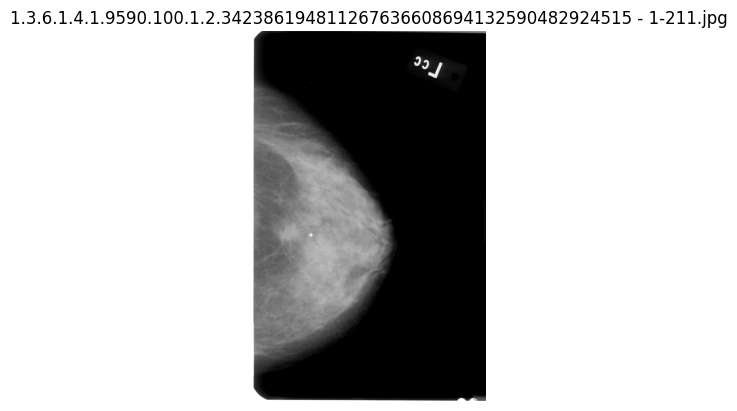

In [13]:
#DDSM Mammography Example
show_one_image_in_dir(full_jpeg_path)

d. Choosing a measure of success
 - Accuracy


#2.   Developing a model




    a. Prearing the data
      - input data: Digital Database for Screening Mammography (DDSM). it can be downloaded from https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
      - the type of machine learning: a binary classification. Malignant or Benign.
      - what do existing solutions look like:
      - constraints: no constrains. it can run on any environments.




In [14]:
#function to normalize pathology. just MALIGNANT and benign
def normalize_pathology(label):
    if pd.isna(label):
        print("Warning: pathology label is NaN")
        return None
    if label == 'MALIGNANT':
        return 'malignant'
    return 'benign'

In [15]:
# apply normalize_pathology for pathology column
# apply get_jpeg_image_path for Image Data Path
# apply get_jpeg_mask_path for Mask Path
# Handle missing values by dropna function
def preprocess_df(df):
    df = df.copy()
    df['label'] = df['pathology'].apply(normalize_pathology)
    df['image_path'] = df.apply(get_jpeg_image_path, axis=1)
    df['mask_path'] = df.apply(get_jpeg_mask_path, axis=1)
    length_before_drop = len(df)
    df = df.dropna(subset=['label', 'image_path', 'mask_path'])
    length_after_drop = len(df)
    print(f"Dropped {length_before_drop - length_after_drop} rows due to missing labels or paths")
    df = df[df['image_path'].apply(os.path.exists)]
    df = df[df['mask_path'].apply(os.path.exists)]
    print(f"Rows after verifying image and mask paths exist: {len(df)}")
    return df

In [16]:
#Prepate train and validation data set
print("Preprocessing calc_train_df...")
calc_train_processed = preprocess_df(calc_train_df)
print("Preprocessing mass_train_df...")
mass_train_processed = preprocess_df(mass_train_df)
train_df = pd.concat([calc_train_processed, mass_train_processed], ignore_index=True)

Preprocessing calc_train_df...
No mask found by unique value heuristic, fallback to: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.323173986211744534717152497940376023803/1-207.jpg
Mask folder does not exist: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.348822970413183698610798947061334416506
Dropped 1 rows due to missing labels or paths
Rows after verifying image and mask paths exist: 1545
Preprocessing mass_train_df...
Dropped 0 rows due to missing labels or paths
Rows after verifying image and mask paths exist: 1318


In [17]:
# Prepare test data set
print("Preprocessing calc_test_df...")
calc_test_processed = preprocess_df(calc_test_df)
print("Preprocessing mass_test_df...")
mass_test_processed = preprocess_df(mass_test_df)
test_df = pd.concat([calc_test_processed, mass_test_processed], ignore_index=True)

Preprocessing calc_test_df...
Dropped 0 rows due to missing labels or paths
Rows after verifying image and mask paths exist: 326
Preprocessing mass_test_df...
Dropped 0 rows due to missing labels or paths
Rows after verifying image and mask paths exist: 378


In [18]:
print("\nSample paths after preprocessing:")
train_df[['image file path', 'image_path', 'mask_path', 'label']].head()


Sample paths after preprocessing:


,image file path,image_path,mask_path,label
0,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,malignant
1,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,malignant
2,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,benign
3,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,benign
4,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,benign



Train set label distribution after normalization:
label
benign       1682
malignant    1181
Name: count, dtype: int64


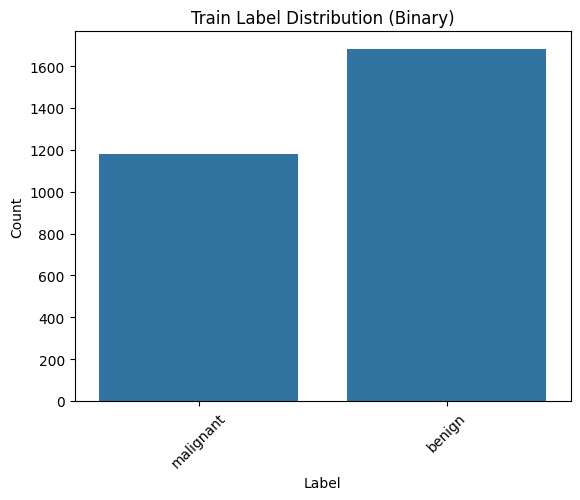

In [19]:
# Check label distribution after normalization
print("\nTrain set label distribution after normalization:")
print(train_df['label'].value_counts())

sns.countplot(x='label', data=train_df)
plt.title('Train Label Distribution (Binary)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [20]:
#function to show images with masks
def show_samples_with_masks(df, label, n=4, random_state=42):
    samples = df[df['label'] == label].sample(n, random_state=random_state)
    plt.figure(figsize=(12, 6))

    for i, (_, row) in enumerate(samples.iterrows()):
            print(f"Showing sample {i+1} for label '{label}':")
            print(f" Image path: {row['image_path']}")
            print(f" Mask path: {row['mask_path']}")

            img = Image.open(row['image_path'])
            plt.subplot(2, n, i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{label}\nImage")
            plt.axis('off')

            mask = Image.open(row['mask_path'])
            plt.subplot(2, n, n + i + 1)
            plt.imshow(mask, cmap='gray')
            plt.title("Mask")
            plt.axis('off')


    plt.tight_layout()
    plt.show()


Sample images and masks for class: malignant
Showing sample 1 for label 'malignant':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.131861114610888161822097220104193388621/1-201.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.261038958613341762712247433262593053162/1-140.jpg
Showing sample 2 for label 'malignant':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.372857232512741811521561294420281719494/1-138.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.360644371912187673603409637413721677692/1-105.jpg
Showing sample 3 for label 'malignant':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.389065219613431726719665409391003097070/1-066.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.38715406031238383

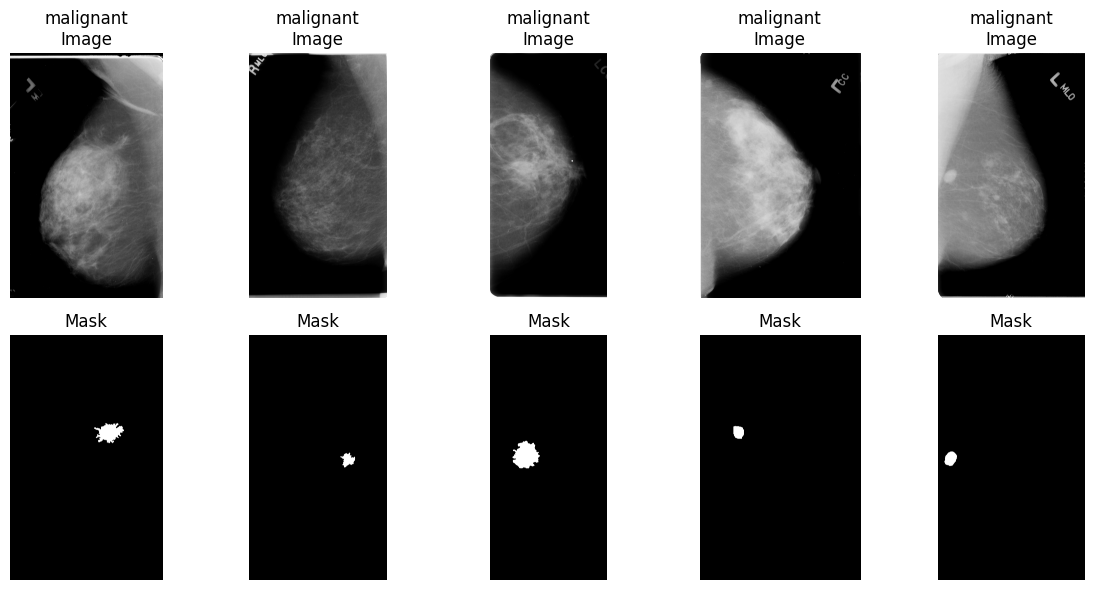


Sample images and masks for class: benign
Showing sample 1 for label 'benign':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.61044218211319887532948581303525540079/1-082.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.275689109211825107611385153593740697706/1-178.jpg
Showing sample 2 for label 'benign':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.409207265212595936741414537543409826717/1-059.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.164907903213907010821320098862085821311/2-213.jpg
Showing sample 3 for label 'benign':
 Image path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12869627612231993827821925170759563675/1-196.jpg
 Mask path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.4142966204109835232365359709425

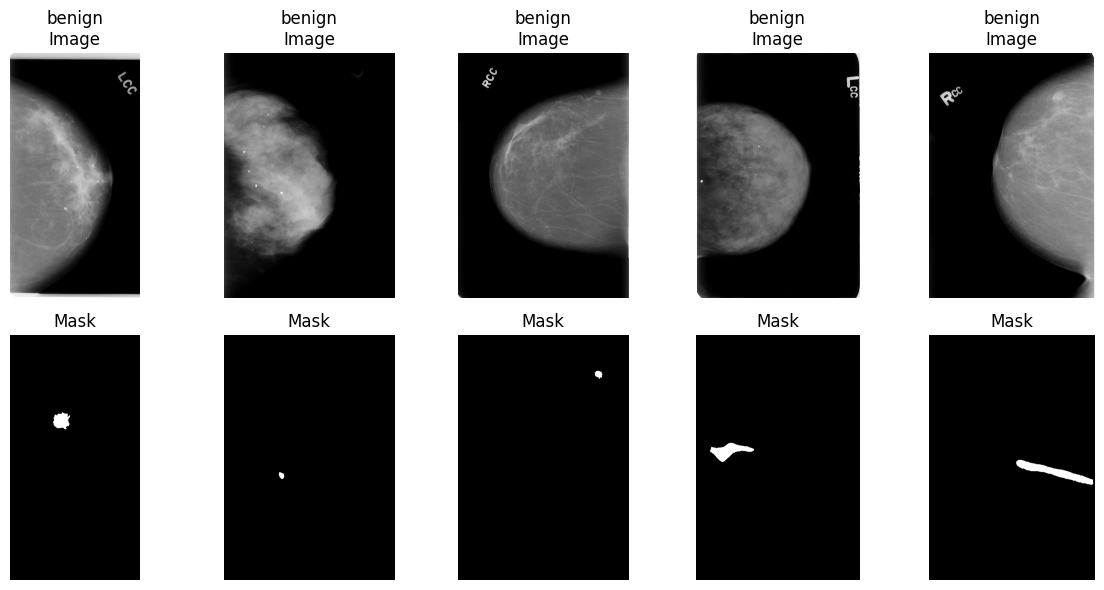

In [21]:
#image examples with masks
for lbl in train_df['label'].unique():
    print(f"\nSample images and masks for class: {lbl}")
    show_samples_with_masks(train_df, lbl, n = 5)

  b. Choosing an evaluation protocol: K-fold Cross Validation Protocol is used. because only 2864 (1546 + 1318) Samples can be used for training, K-fold cross validation is utilized to compensate for the small sample size.
  

c. Beating a baseline: a resnet 152 with 5 fold model will be trained.

In [22]:
#define train_transform and val_test_transform
# Resize: resizes the input image to a fixed size of 224x224 pixels
# Grayscale(num_output_channels =3 ): Converts the grascale images to a 3 channel format. 3 input channel is used for pre-trained model like ResNet
# RandomHorizontalFlip(p=0.5): Flips the image horizontally with a 50% probability.
# RandomVerticalFlip(p=0.5): Flips the image vertically with a 50% probability.
#RandomRotation(15): Rotates the image by an anlge up to 15 degrees.
# RandomAffine: Rotation up to 15 degrees, Translation up to 20% width and height, Scale from 80% to 120%
# ColorJitter: Changes the brightness and Contrast of the image randomly by up to 20%
# ToTensor: Transform the image to a PyTorch Tensor
# Normalize: Normalize the Tensor Image with the Pre-Trained ImageNet Images Mean and Standard Deviation.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5), # Add RandomVerticalFlip for more augmentation
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=15, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

In [23]:
#define class MammogramDataset
class MammogramDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_map = {'benign': 0, 'malignant': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img = Image.open(row['image_path']).convert('L')
        if self.transform:
            img = self.transform(img)
        label = self.label_map[row['label']]
        return img, label

In [38]:
# Create Train Datasets
train_dataset = MammogramDataset(train_df, transform=train_transform)

In [39]:
#class weights to address class imblance
print("➡️ Creating weighted sampler to address class imbalance...")
class_counts = train_df['label'].value_counts()
class_weights = torch.tensor([1.0 / class_counts['benign'], 1.0 / class_counts['malignant']]).float()
print(f"Class counts: {class_counts.to_dict()}")
print(f"Class weights: {class_weights}")

➡️ Creating weighted sampler to address class imbalance...
Class counts: {'benign': 1682, 'malignant': 1181}
Class weights: tensor([0.0006, 0.0008])


In [41]:
# Create sample weights for each training sample, skip None samples
sample_weights = []
for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    if img is not None and label is not None:
        sample_weights.append(class_weights[label].item())
    else:
        sample_weights.append(0)  # Will be ignored

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [42]:
# Create DataLoaders with a custom collate_fn to filter out None samples
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None and x[1] is not None, batch))
    return torch.utils.data.dataloader.default_collate(batch)

In [43]:
# resnet152 with IMAGENET1K_V2 model
model152= models.resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
#print(model152)

In [44]:
# Unfreeze layers for fine-tuning
def unfreeze_model(model, layer1_requires_grad=False, layer2_requires_grad = True, layer3_requires_grad = True, layer4_requires_grad = True, ):
  for param in model.parameters():
    param.requires_grad = False
  if layer1_requires_grad:
    for param in model.layer1.parameters():
        param.requires_grad = True
  if layer2_requires_grad:
    for param in model.layer2.parameters():
        param.requires_grad = True
  if layer3_requires_grad:
    for param in model.layer3.parameters():
        param.requires_grad = True
  if layer4_requires_grad:
    for param in model.layer4.parameters():
        param.requires_grad = True
  for param in model.fc.parameters():
    param.requires_grad = True

In [45]:
unfreeze_model(model152, layer1_requires_grad=True, layer2_requires_grad=True, layer3_requires_grad=True, layer4_requires_grad=True)
print("model152 unfrozen with layer1, layer2, layer3, and layer4 requiring gradients.")

model152 unfrozen with layer1, layer2, layer3, and layer4 requiring gradients.


In [46]:
# Modify the final layer for binary classification
def modify_fully_connected_layer(model):
  num_ftrs = model.fc.in_features
  model.fc = nn.Linear(num_ftrs, 2)

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)
  return model, device

model152, device152 = modify_fully_connected_layer(model152)

In [29]:
# function to train for one epoch
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(dataloader, desc="Training"):
        if images is None or labels is None:
            continue
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss / total if total > 0 else float('inf')
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc

In [30]:
# function to evaluate data with model
def evaluate(model, dataloader, criterion, device, return_preds=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            if images is None or labels is None:
                continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
    eval_loss = running_loss / total if total > 0 else float('inf')
    eval_acc = correct / total if total > 0 else 0.0
    return (eval_loss, eval_acc, all_preds, all_labels) if return_preds else (eval_loss, eval_acc)

In [47]:
# optimizer
def optimizer_for_model2(model, device, class_weights):
  class_weights = class_weights.to(device) # FocalLoss does not directly take class weights
  criterion = nn.CrossEntropyLoss(weight=class_weights)

  optimizer = optim.Adam([
      {'params': model.fc.parameters(), 'lr': 1e-4},
      {'params': model.layer1.parameters(), 'lr': 1e-6},
      {'params': model.layer2.parameters(), 'lr': 1e-6}, #1e-5},
      {'params': model.layer3.parameters(), 'lr': 1e-6}, #1e-5},
      {'params': model.layer4.parameters(), 'lr': 1e-6}, #1e-5}
  ], weight_decay=1e-5)
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
  return optimizer, criterion, scheduler

optimizer152, criterion152, scheduler152 = optimizer_for_model2(model152, device152, class_weights)
print("Optimizer, criterion, and scheduler re-initialized for model152 with updated learning rates (using Adam).")

Optimizer, criterion, and scheduler re-initialized for model152 with updated learning rates (using Adam).


In [51]:
# Training loop function
def training(model, optimizer, criterion, device, train_loader, val_loader, scheduler, num_epochs=40, patience=10, id='00'):
  #num_epochs = 40
  #patience = 10   # Increased patience
  best_acc = 0.0
  trigger_times = 0
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  for epoch in range(num_epochs):
      train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
      val_loss, val_acc = evaluate(model, val_loader, criterion, device)

      train_losses.append(train_loss)
      train_accs.append(train_acc)
      val_losses.append(val_loss)
      val_accs.append(val_acc)

      print(f"Epoch {epoch+1}/{num_epochs}:")
      print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
      print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

      scheduler.step(val_acc)

      if val_acc > best_acc:
          best_acc = val_acc
          trigger_times = 0
          torch.save(model.state_dict(), 'best_resnet_model' + id + '.pth')
          print("  ✓ Best model saved.")
      else:
          trigger_times += 1
          if trigger_times >= patience:
              print("  ✗ Early stopping triggered.")
              break
  return train_losses, val_losses, train_accs, val_accs

In [48]:
#function to train with k-fold
from sklearn.model_selection import KFold

def train_with_kfold(base_model, train_df, MammogramDataset, train_transform, val_test_transform, class_weights, num_epochs=40, patience=10, k_splits=5):
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)
    fold_results = []

    print(f"\n--- Starting K-Fold Cross-Validation with {k_splits} folds ---")

    for fold, (train_index, val_index) in enumerate(kf.split(train_df)):
        print(f"\n>>> Fold {fold + 1}/{k_splits}")

        fold_train_df = train_df.iloc[train_index]
        fold_val_df = train_df.iloc[val_index]

        # Create Datasets for the current fold
        fold_train_dataset = MammogramDataset(fold_train_df, transform=train_transform)
        fold_val_dataset = MammogramDataset(fold_val_df, transform=val_test_transform)

        # Create sample weights for the current fold's training set
        fold_class_counts = fold_train_df['label'].value_counts()
        # Handle cases where a class might be missing in a fold (though unlikely with stratify)
        fold_class_weights_list = [
            1.0 / fold_class_counts.get('benign', 1.0), # Default to 1.0 to avoid division by zero
            1.0 / fold_class_counts.get('malignant', 1.0)
        ]
        fold_class_weights = torch.tensor(fold_class_weights_list).float()

        fold_sample_weights = []
        for i in range(len(fold_train_dataset)):
            img, label = fold_train_dataset[i]
            if img is not None and label is not None:
                fold_sample_weights.append(fold_class_weights[label].item())
            else:
                fold_sample_weights.append(0) # Will be ignored

        fold_sampler = WeightedRandomSampler(fold_sample_weights, len(fold_sample_weights))

        # Create DataLoaders for the current fold
        fold_train_loader = DataLoader(fold_train_dataset, batch_size=32, sampler=fold_sampler, num_workers=4, collate_fn=collate_fn)
        fold_val_loader = DataLoader(fold_val_dataset, batch_size=32, shuffle=False, num_workers=4, collate_fn=collate_fn)

        # initialize model, optimizer, and criterion for each fold
        model_fold = models.resnet152(weights=ResNet152_Weights.IMAGENET1K_V2) # Load pre-trained weights
        unfreeze_model(model_fold, layer1_requires_grad=True, layer2_requires_grad=True, layer3_requires_grad=True, layer4_requires_grad=True)
        model_fold, device_fold = modify_fully_connected_layer(model_fold)
        optimizer_fold, criterion_fold, scheduler_fold = optimizer_for_model2(model_fold, device_fold, fold_class_weights)

        # Train the model for the current fold
        fold_train_losses, fold_val_losses, fold_train_accs, fold_val_accs = training(
            model_fold, optimizer_fold, criterion_fold, device_fold, fold_train_loader, fold_val_loader,
            scheduler_fold, num_epochs=num_epochs, patience=patience, id=f'152_fold_{fold+1}'
        )

        # Load the best model saved during training for this fold
        model_fold.load_state_dict(torch.load(f'best_resnet_model152_fold_{fold+1}.pth'))

        # Evaluate on the validation set of this fold
        _, val_acc, _, _ = evaluate(model_fold, fold_val_loader, criterion_fold, device_fold, return_preds=True)
        fold_results.append(val_acc)
        print(f"Fold {fold + 1} Validation Accuracy: {val_acc:.4f}")

    avg_val_acc = sum(fold_results) / len(fold_results)
    print(f"\n--- K-Fold Cross-Validation Complete ---")
    print(f"Average Validation Accuracy across {k_splits} folds: {avg_val_acc:.4f}")
    return avg_val_acc, fold_results

In [54]:
# to call the k-fold training function
avg_val_acc, fold_individual_accs = train_with_kfold(
    model152,
    train_df,
    MammogramDataset,
    train_transform,
    val_test_transform,
    class_weights,
    num_epochs=100,
    patience=20,
    k_splits=5
)
print(f"Final Average K-Fold Validation Accuracy: {avg_val_acc:.4f}")


--- Starting K-Fold Cross-Validation with 5 folds ---

>>> Fold 1/5


Evaluating: 100%|██████████| 18/18 [00:05<00:00,  3.01it/s]


Epoch 1/100:
  Train Loss: 0.6731 | Train Acc: 0.5061
  Val   Loss: 0.6809 | Val   Acc: 0.5393
  ✓ Best model saved.


Evaluating: 100%|██████████| 18/18 [00:05<00:00,  3.03it/s]


Epoch 2/100:
  Train Loss: 0.6649 | Train Acc: 0.5227
  Val   Loss: 0.6851 | Val   Acc: 0.5515
  ✓ Best model saved.


...

Epoch 36/100:
  Train Loss: 0.6075 | Train Acc: 0.6683
  Val   Loss: 0.6430 | Val   Acc: 0.6451


Evaluating: 100%|██████████| 18/18 [00:06<00:00,  2.95it/s]


Epoch 37/100:
  Train Loss: 0.6116 | Train Acc: 0.6530
  Val   Loss: 0.6412 | Val   Acc: 0.6381
  ✗ Early stopping triggered.


Evaluating: 100%|██████████| 18/18 [00:06<00:00,  2.92it/s]

Fold 5 Validation Accuracy: 0.6451

--- K-Fold Cross-Validation Complete ---
Average Validation Accuracy across 5 folds: 0.6647
Final Average K-Fold Validation Accuracy: 0.6647


In [57]:
# Create Test Dataset and DataLoader to evaluate
test_dataset = MammogramDataset(test_df, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, collate_fn=collate_fn)

print(f"Valid test samples: {len(test_dataset)}")

Valid test samples: 704


In [58]:
# load one model for sample test purpose

model152_test = models.resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
unfreeze_model(model152_test, layer1_requires_grad=True, layer2_requires_grad=True, layer3_requires_grad=True, layer4_requires_grad=True)
model152_test, device152_test = modify_fully_connected_layer(model152_test)

# Load the state dictionary of the best model from a specific fold (e.g., Fold 1)
model152_test.load_state_dict(torch.load('best_resnet_model152_fold_1.pth'))
model152_test = model152_test.to(device152_test)
print("Loaded best_resnet_model152_fold_1.pth for test evaluation.")

Loaded best_resnet_model152_fold_1.pth for test evaluation.


In [59]:
# Evaluate the loaded model on the test dataset for sample test purpose
_, criterion_eval, _ = optimizer_for_model2(model152_test, device152_test, class_weights)

test_loss, test_acc, all_preds_test, all_labels_test = evaluate(model152_test, test_loader, criterion_eval, device152_test, return_preds=True)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating: 100%|██████████| 22/22 [00:08<00:00,  2.57it/s]


Test Loss: 0.6546
Test Accuracy: 0.6207


In [62]:
# load models for evaluation test
num_folds = 5 # Based on k_splits=5 used in train_with_kfold
all_fold_test_accuracies = []
all_fold_test_losses = []

print(f"\n--- Evaluating Test Set with Best Model from Each of {num_folds} Folds ---")

for fold in range(num_folds):
    print(f"\nEvaluating Fold {fold + 1} Best Model on Test Set...")

    # Re-initialize model architecture for each fold's evaluation
    model_fold_test = models.resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
    unfreeze_model(model_fold_test, layer1_requires_grad=True, layer2_requires_grad=True, layer3_requires_grad=True, layer4_requires_grad=True)
    model_fold_test, device_fold_test = modify_fully_connected_layer(model_fold_test)

    # Load the best model's state dict for the current fold
    model_path = f'best_resnet_model152_fold_{fold+1}.pth'
    model_fold_test.load_state_dict(torch.load(model_path))
    model_fold_test = model_fold_test.to(device_fold_test)
    print(f"Loaded {model_path}")

    # Re-initialize criterion for evaluation (class_weights should be consistent)
    # Using the class_weights from the full training set as a proxy
    _, criterion_eval_fold, _ = optimizer_for_model2(model_fold_test, device_fold_test, class_weights)

    test_loss_fold, test_acc_fold = evaluate(model_fold_test, test_loader, criterion_eval_fold, device_fold_test, return_preds=False)

    print(f"  Fold {fold + 1} Test Loss: {test_loss_fold:.4f}")
    print(f"  Fold {fold + 1} Test Accuracy: {test_acc_fold:.4f}")

    all_fold_test_accuracies.append(test_acc_fold)
    all_fold_test_losses.append(test_loss_fold)

# Summarize results
mean_test_acc = np.mean(all_fold_test_accuracies)
std_test_acc = np.std(all_fold_test_accuracies)
mean_test_loss = np.mean(all_fold_test_losses)
std_test_loss = np.std(all_fold_test_losses)

print(f"\n--- Summary of Test Set Evaluation Across All Folds ---")
print(f"Average Test Accuracy: {mean_test_acc:.4f} (Std Dev: {std_test_acc:.4f})")
print(f"Average Test Loss: {mean_test_loss:.4f} (Std Dev: {std_test_loss:.4f})")


--- Evaluating Test Set with Best Model from Each of 5 Folds ---

Evaluating Fold 1 Best Model on Test Set...
Loaded best_resnet_model152_fold_1.pth


Evaluating: 100%|██████████| 22/22 [00:07<00:00,  3.00it/s]


  Fold 1 Test Loss: 0.6546
  Fold 1 Test Accuracy: 0.6207

Evaluating Fold 2 Best Model on Test Set...
Loaded best_resnet_model152_fold_2.pth


Evaluating: 100%|██████████| 22/22 [00:07<00:00,  3.02it/s]


  Fold 2 Test Loss: 0.6668
  Fold 2 Test Accuracy: 0.5895

Evaluating Fold 3 Best Model on Test Set...
Loaded best_resnet_model152_fold_3.pth


...

  Fold 3 Test Loss: 0.6910
  Fold 3 Test Accuracy: 0.6207

Evaluating Fold 4 Best Model on Test Set...
Loaded best_resnet_model152_fold_4.pth


Evaluating: 100%|██████████| 22/22 [00:07<00:00,  3.03it/s]


  Fold 4 Test Loss: 0.6788
  Fold 4 Test Accuracy: 0.6222

Evaluating Fold 5 Best Model on Test Set...
Loaded best_resnet_model152_fold_5.pth


Evaluating: 100%|██████████| 22/22 [00:07<00:00,  2.99it/s]

  Fold 5 Test Loss: 0.6533
  Fold 5 Test Accuracy: 0.6378

--- Summary of Test Set Evaluation Across All Folds ---
Average Test Accuracy: 0.6182 (Std Dev: 0.0157)
Average Test Loss: 0.6689 (Std Dev: 0.0144)


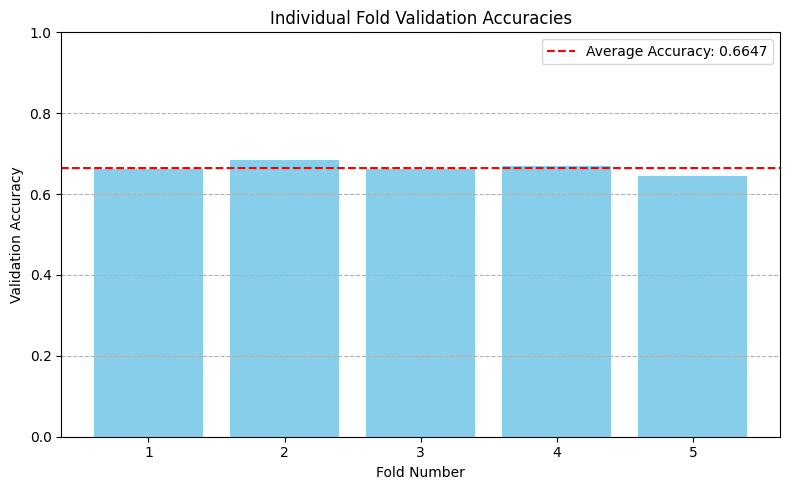

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_individual_accs) + 1), fold_individual_accs, color='skyblue')
plt.axhline(y=avg_val_acc, color='r', linestyle='--', label=f'Average Accuracy: {avg_val_acc:.4f}')
plt.title('Individual Fold Validation Accuracies')
plt.xlabel('Fold Number')
plt.ylabel('Validation Accuracy')
plt.xticks(range(1, len(fold_individual_accs) + 1))
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [63]:
# function to k-fold evaluation for test data
kfold_models = []
num_folds = 5 # As defined in train_with_kfold
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading {num_folds} K-fold models...")

for fold in range(num_folds):
    print(f"Loading model for Fold {fold + 1}...")

    # a. Initialize a new models.resnet152 model with pre-trained weights
    model_fold = models.resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

    # b. Call the unfreeze_model function
    unfreeze_model(model_fold, layer1_requires_grad=True, layer2_requires_grad=True, layer3_requires_grad=True, layer4_requires_grad=True)

    # c. Call the modify_fully_connected_layer function and ensure it's moved to the determined device
    # The modify_fully_connected_layer function already moves the model to the device
    model_fold, _ = modify_fully_connected_layer(model_fold)

    # d. Construct the path to the saved model state dictionary for the current fold
    model_path = f'best_resnet_model152_fold_{fold+1}.pth'

    # e. Load the state dictionary into the current model
    model_fold.load_state_dict(torch.load(model_path, map_location=device))

    # f. Set the current model to evaluation mode
    model_fold.eval()

    # g. Append the loaded and configured model to the kfold_models list
    kfold_models.append(model_fold)

print(f"Successfully loaded {len(kfold_models)} models.")

Loading 5 K-fold models...
Loading model for Fold 1...
Loading model for Fold 2...
Loading model for Fold 3...
Loading model for Fold 4...
Loading model for Fold 5...
Successfully loaded 5 models.


In [64]:
# to make 5 models predictions list
all_model_predictions = []

print("Collecting predictions from each K-fold model...")

for i, model in enumerate(kfold_models):
    print(f"Making predictions with model from Fold {i + 1}...")
    fold_predictions = []
    with torch.no_grad(): # Disable gradient calculations for inference
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            fold_predictions.append(outputs.cpu()) # Store predictions on CPU

    all_model_predictions.append(torch.cat(fold_predictions, dim=0))

# Convert list of tensors to a single tensor for easier ensembling
# This will result in a shape like (num_models, num_test_samples, num_classes)
all_model_predictions_tensor = torch.stack(all_model_predictions)

print(f"Successfully collected predictions from {len(kfold_models)} models.")
print(f"Shape of all_model_predictions_tensor: {all_model_predictions_tensor.shape}")

Making predictions with model from Fold 1...
Making predictions with model from Fold 2...
Making predictions with model from Fold 3...
Making predictions with model from Fold 4...
Making predictions with model from Fold 5...
Successfully collected predictions from 5 models.
Shape of all_model_predictions_tensor: torch.Size([5, 704, 2])


Ensemble Model Accuracy: 0.6335

--- Individual Model Accuracies ---
Fold 1 Test Accuracy: 0.6207
Fold 2 Test Accuracy: 0.5895
Fold 3 Test Accuracy: 0.6207
Fold 4 Test Accuracy: 0.6222
Fold 5 Test Accuracy: 0.6378

Average Individual Model Accuracy: 0.6182 (Std Dev: 0.0157)


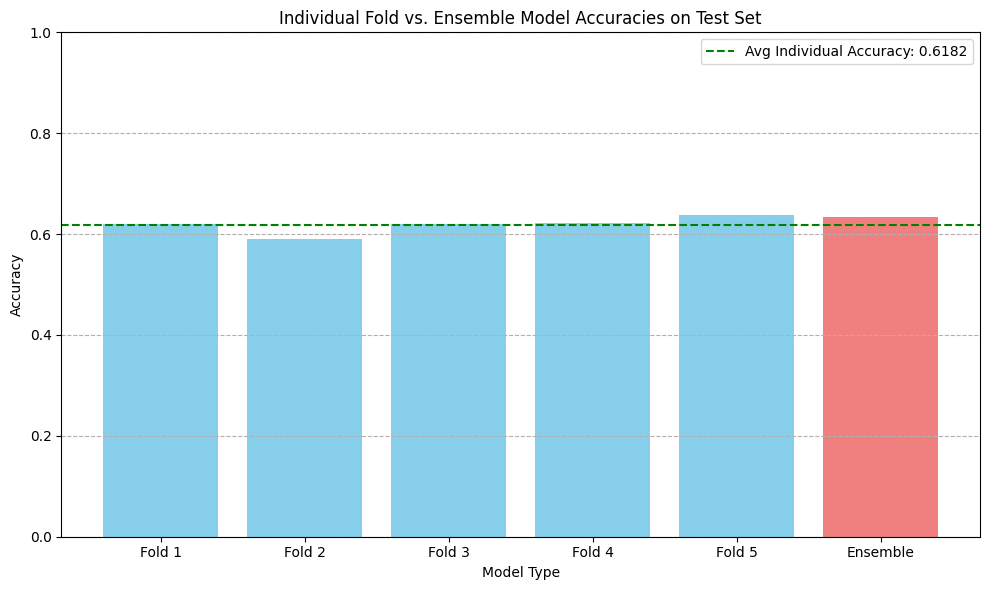

In [66]:
#to make predictions with ensemble model
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensemble Predictions: Calculate the average of the all_model_predictions_tensor
# This gives the average logits from all models for each sample
ensembled_logits = torch.mean(all_model_predictions_tensor, dim=0)

# 2. Ensemble Predictions: Convert ensembled logits ->  labels
_, ensemble_preds = torch.max(ensembled_logits, 1);
ensemble_preds_np = ensemble_preds.cpu().numpy()

# 3.Get true labels from the test_dataset
true_labels_np = np.array(all_labels_test)

# 4. Evaluate Ensemble Performance: Calculate the accuracy
ensemble_accuracy = np.mean(ensemble_preds_np == true_labels_np)
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")

# 5. Compare with Individual Models
print("\n--- Individual Model Accuracies ---")
for i, acc in enumerate(all_fold_test_accuracies):
    print(f"Fold {i+1} Test Accuracy: {acc:.4f}")

mean_individual_acc = np.mean(all_fold_test_accuracies)
std_individual_acc = np.std(all_fold_test_accuracies)
print(f"\nAverage Individual Model Accuracy: {mean_individual_acc:.4f} (Std Dev: {std_individual_acc:.4f})")


labels = [f'Fold {i+1}' for i in range(num_folds)] + ['Ensemble']
accuracies = all_fold_test_accuracies + [ensemble_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(labels, accuracies, color=['skyblue'] * num_folds + ['lightcoral'])
plt.axhline(y=mean_individual_acc, color='green', linestyle='--', label=f'Avg Individual Accuracy: {mean_individual_acc:.4f}')
plt.title('Individual Fold vs. Ensemble Model Accuracies on Test Set')
plt.xlabel('Model Type')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


--- Ensemble Model Classification Report ---
              precision    recall  f1-score   support

      benign       0.71      0.67      0.69       428
   malignant       0.53      0.58      0.56       276

    accuracy                           0.63       704
   macro avg       0.62      0.62      0.62       704
weighted avg       0.64      0.63      0.64       704



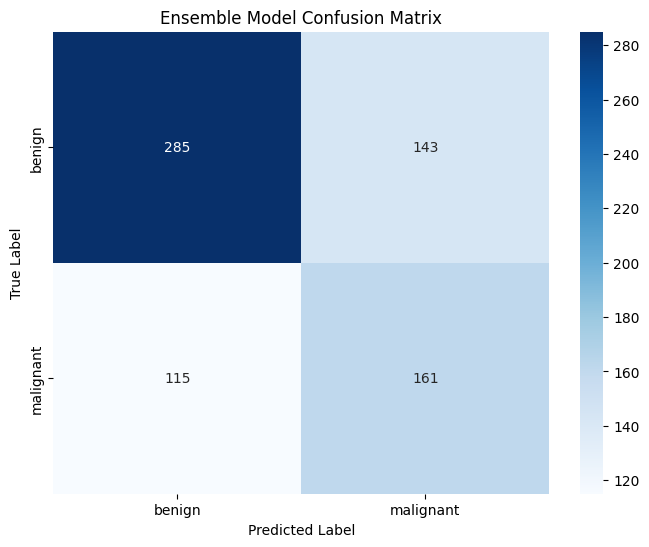

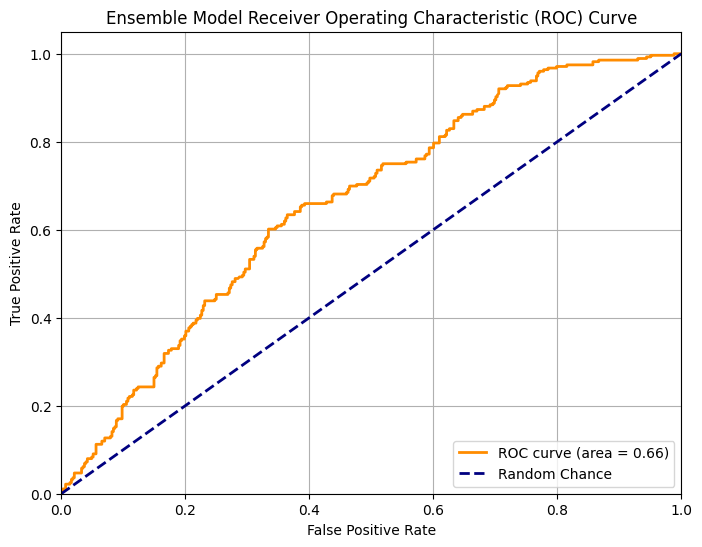

In [67]:
#Confusion Matrix and ROC Curve
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Classification Report
print("\n--- Ensemble Model Classification Report ---")
print(classification_report(true_labels_np, ensemble_preds_np, target_names=['benign', 'malignant']))

# 2. Confusion Matrix
cm = confusion_matrix(true_labels_np, ensemble_preds_np)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
plt.title('Ensemble Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. ROC Curve and AUC
# Calculate probabilities for the positive class (malignant)
ensemble_probs = torch.softmax(ensembled_logits, dim=1)[:, 1].cpu().numpy()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels_np, ensemble_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Model Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [89]:
# find one true positive sample for Explainability Feature of the model
true_positive_idx = None
for i in range(len(true_labels_np)):
    if true_labels_np[i] == 1 and ensemble_preds_np[i] == 1:
        true_positive_idx = i
        break

if true_positive_idx is not None:
    print(f"Found first true positive 'malignant' sample at index: {true_positive_idx}")
else:
    print("No true positive 'malignant' sample found.")

Found first true positive 'malignant' sample at index: 16


In [90]:
# GradCAM Class
import torch
import torch.nn.functional as F
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None
        self.gradients = None
        self.handlers = []

        self._register_hooks()

    def _register_hooks(self):
        # Register hook for feature maps (forward pass)
        self.handlers.append(self.target_layer.register_forward_hook(self._save_feature_maps_hook))
        # Register hook for gradients (backward pass)
        self.handlers.append(self.target_layer.register_backward_hook(self._save_gradients_hook))

    def _save_feature_maps_hook(self, module, input, output):
        self.feature_maps = output.detach()

    def _save_gradients_hook(self, module, grad_input, grad_output):
        # grad_output is a tuple, we are interested in the gradient of the output
        self.gradients = grad_output[0].detach()

    def __call__(self, input_image, target_class=None):
        self.model.eval()
        self.model.zero_grad()

        # Forward pass
        output = self.model(input_image) # output are logits

        if target_class is None:
            # Get the predicted class if target_class is not specified
            target_class = output.argmax(dim=1).item()

        # Backward pass for the target class
        # Create a one-hot vector for the target class
        one_hot = torch.zeros_like(output, dtype=torch.float)
        one_hot[0][target_class] = 1 # Assuming batch size of 1 for simplicity

        # Compute gradients of the target class score with respect to outputs
        # Retain graph is set to True to allow subsequent backward calls if needed (e.g., for multiple Grad-CAMs)
        output.backward(gradient=one_hot, retain_graph=True)

        # Get feature maps and gradients
        feature_maps = self.feature_maps
        gradients = self.gradients

        # Compute alpha weights (global average pooling of gradients)
        # These weights represent the importance of each feature map channel
        weights = F.adaptive_avg_pool2d(gradients, 1)

        # Compute Grad-CAM heatmap
        # Perform a weighted sum of the feature maps using the calculated alpha weights
        cam = (weights * feature_maps).sum(dim=1, keepdim=True)
        cam = F.relu(cam) # Apply ReLU to keep only positive contributions (features that positively influence the prediction)

        # Normalize and resize the heatmap
        cam = F.interpolate(cam, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8) # Add small epsilon to avoid division by zero

        return cam.squeeze().cpu().numpy()

    def remove_hooks(self):
        for handler in self.handlers:
            handler.remove()

# Instantiate GradCAM using the first K-fold model and its last convolutional layer
# For ResNet152 in the final block (layer4) is 'conv3'.
target_model = kfold_models[0]
target_layer_for_cam = target_model.layer4[-1].conv3

grad_cam = GradCAM(target_model, target_layer_for_cam)
print("GradCAM instance created successfully.")

GradCAM instance created successfully.


In [91]:
import matplotlib.pyplot as plt

# 1. Retrieve the row corresponding to true_positive_idx from the test_df
original_test_row = test_df.iloc[true_positive_idx]

# 2. Open the image file and convert it to grayscale
original_image = Image.open(original_test_row['image_path']).convert('L')

# 3. Apply the val_test_transform and add a batch dimension
input_tensor = val_test_transform(original_image).unsqueeze(0)

# 4. Move the transformed input image to the device
input_tensor = input_tensor.to(device)

# 5. Generate the Grad-CAM heatmap
target_class = 1 # Malignant
heatmap = grad_cam(input_tensor, target_class=target_class)

print(f"Grad-CAM heatmap generated for sample at index {true_positive_idx} (True Label: {original_test_row['label']}, Predicted by Ensemble: malignant).")

Grad-CAM heatmap generated for sample at index 16 (True Label: malignant, Predicted by Ensemble: malignant).


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


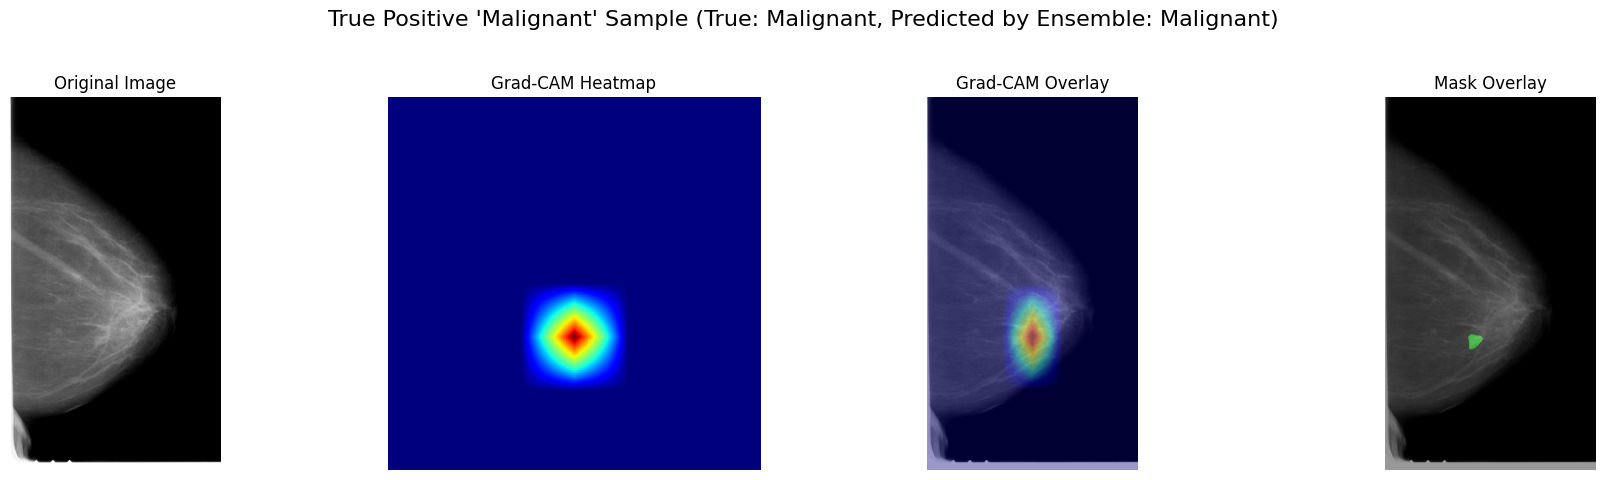

In [93]:
# compare original image, Grad-CAM Heatmap, Grad-CAM overlay, Mask overlay for one True Positive (Malignant) image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# 1. Retrieve the file path to the ROI mask image
mask_image_path = original_test_row['mask_path']

# 2. Open the ROI mask image and convert it to grayscale
mask_image = Image.open(mask_image_path).convert('L')

# Get true and predicted labels as strings for the title
true_label_str = original_test_row['label']
predicted_label_str = 'malignant' if ensemble_preds_np[true_positive_idx] == 1 else 'benign'

# 3. Create a figure with 4 subplots
plt.figure(figsize=(19, 5)) # Adjusted width for 4 subplots

# 4a. Original Image
plt.subplot(1, 4, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 4b. Grad-CAM Heatmap
plt.subplot(1, 4, 2)
plt.imshow(heatmap, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

# 4c. Grad-CAM Overlay
superimposed_image = visualize_cam(original_image, heatmap)
plt.subplot(1, 4, 3)
plt.imshow(superimposed_image)
plt.title('Grad-CAM Overlay')
plt.axis('off')

# 4d. Mask Overlay Image
plt.subplot(1, 4, 4)
plt.imshow(mask_overlay_image)
plt.title('Mask Overlay')
plt.axis('off')

# 5. Add a main title to the entire figure
plt.suptitle(f"True Positive 'Malignant' Sample (True: {true_label_str.capitalize()}, Predicted by Ensemble: {predicted_label_str.capitalize()})", fontsize=16)

# 6. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

# 7. Display the plot
plt.show()



#3.   Deplying a model

this model is provided with jupyter nutebook